## Graph Sentinel — Bitcoin OTC Trust Network
**Fraud Detection in Peer-to-Peer Financial Networks using Temporal GNN**

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import math, random, warnings
from sklearn.metrics import (precision_recall_curve, auc,
                             roc_auc_score, confusion_matrix,
                             classification_report)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
print("Imports done.")


Imports done.


### Cell 2 — Load Bitcoin OTC dataset

In [2]:
# Cell 2 — Load & preprocess
# Format: SOURCE, TARGET, RATING, TIME
# Label: negative rating (< 0) = fraudulent/untrusted trader

print("Loading Bitcoin OTC dataset...")
df = pd.read_csv("Dataset/soc-sign-bitcoinotc.csv",
                 header=None,
                 names=['user_id', 'item_id', 'rating', 'timestamp'])

print(f"Loaded {len(df):,} interactions")

# Sort by time
df = df.sort_values('timestamp').reset_index(drop=True)

# ── Label: 1 = negative rating (untrusted/fraudulent), 0 = positive (trusted) ─
df['state_label'] = (df['rating'] < 0).astype(int)

print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index().to_string())
print(f"\nFraud (negative rating): {df['state_label'].sum():,} / {len(df):,}"
      f"  ({df['state_label'].mean()*100:.1f}%)")
print(df[['user_id','item_id','timestamp','rating','state_label']].head(5))


Loading Bitcoin OTC dataset...
Loaded 35,592 interactions

Rating distribution:
rating
-10     2413
-9        20
-8        31
-7        14
-6         5
-5       179
-4        27
-3        91
-2       182
-1       601
 1     20048
 2      5562
 3      2561
 4       967
 5      1268
 6       265
 7       208
 8       277
 9       108
 10      765

Fraud (negative rating): 3,563 / 35,592  (10.0%)
   user_id  item_id     timestamp  rating  state_label
0        6        2  1.289242e+09       4            0
1        6        5  1.289242e+09       2            0
2        1       15  1.289243e+09       1            0
3        4        3  1.289245e+09       7            0
4       13       16  1.289254e+09       8            0


### Cell 3 — Build feature tensor

In [3]:
# Cell 3 — Graph-history features (computed from PAST interactions only)
# Key insight: the signal is in WHO rates WHOM and HOW OFTEN, not time-of-day.
# All features are computed from history BEFORE each interaction → zero leakage.

print("Building graph-history features (this takes ~30 seconds)...")

df_sorted = df.sort_values('timestamp').reset_index(drop=True)

n = len(df_sorted)

# Per-user running stats (computed strictly from past interactions)
user_total_given     = {}   # total ratings given so far
user_neg_given       = {}   # negative ratings given so far
user_total_received  = {}   # total ratings received so far
user_neg_received    = {}   # negative ratings received so far

feat_rows = []

for idx, row in enumerate(df_sorted.itertuples(index=False)):
    u  = row.user_id
    it = row.item_id

    # --- Features from PAST history (before this interaction) ---

    # Rater (u) history
    u_total   = user_total_given.get(u, 0)
    u_neg     = user_neg_given.get(u, 0)
    u_neg_rat = u_neg / max(u_total, 1)       # rater's neg ratio so far

    # Ratee (item_id = target user) history
    t_total   = user_total_received.get(it, 0)
    t_neg     = user_neg_received.get(it, 0)
    t_neg_rat = t_neg / max(t_total, 1)       # target's neg ratio so far

    # Time feature
    t_vals_f  = float(row.timestamp)

    feat_rows.append([
        float(u_total),           # how many ratings rater has given
        float(u_neg_rat),         # rater's historical neg ratio
        float(t_total),           # how many ratings target has received
        float(t_neg_rat),         # target's historical neg ratio
        float(u_total + t_total), # combined activity
        float(u_total == 0),      # rater is new (cold start)
        float(t_total == 0),      # target is new (cold start)
    ])

    # NOW update counts after recording features (strict past-only)
    is_neg = int(row.state_label)
    user_total_given[u]    = u_total + 1
    user_neg_given[u]      = u_neg + is_neg
    user_total_received[it] = t_total + 1
    user_neg_received[it]   = t_neg + is_neg

print(f"Done. Built {len(feat_rows):,} feature vectors")

features_np = np.array(feat_rows, dtype=np.float32)

# Normalize
feat_mean   = features_np.mean(axis=0, keepdims=True)
feat_std    = features_np.std(axis=0, keepdims=True) + 1e-6
features_np = (features_np - feat_mean) / feat_std

features_tensor = torch.from_numpy(features_np)
print(f"Feature tensor : {features_tensor.shape}")
print(f"Features: u_total_given, u_neg_ratio, t_total_received,")
print(f"          t_neg_ratio, combined_activity, u_is_new, t_is_new")
print(f"Zero leakage — all computed from past interactions only")


Building graph-history features (this takes ~30 seconds)...
Done. Built 35,592 feature vectors
Feature tensor : torch.Size([35592, 7])
Features: u_total_given, u_neg_ratio, t_total_received,
          t_neg_ratio, combined_activity, u_is_new, t_is_new
Zero leakage — all computed from past interactions only


### Cell 4 — Index mapping + time buckets

In [4]:
# Cell 4 — Indices + time buckets
print("Building index maps...")
user2idx = {u: i for i, u in enumerate(df['user_id'].unique())}
item2idx = {i: j for j, i in enumerate(df['item_id'].unique())}

df['u_idx'] = df['user_id'].map(user2idx).astype(int)
df['i_idx'] = df['item_id'].map(item2idx).astype(int)

num_users = len(user2idx)
num_items = len(item2idx)

t_min_ts, t_max_ts = df['timestamp'].min(), df['timestamp'].max()
time_span = max(t_max_ts - t_min_ts, 1)
df['t_bucket'] = ((df['timestamp'] - t_min_ts) / time_span * 10).astype(int).clip(0, 9)

print(f"Unique users : {num_users:,}")
print(f"Unique targets: {num_items:,}")
print(f"Time span    : {(t_max_ts - t_min_ts)/86400:.0f} days")


Building index maps...
Unique users : 4,814
Unique targets: 5,858
Time span    : 1903 days


### Cell 5 — Model

In [5]:
# Cell 5 — TemporalModel
class TemporalModel(nn.Module):
    def __init__(self, dim, feature_dim):
        super().__init__()
        self.feat_proj  = nn.Linear(feature_dim, 32)
        self.gru_user   = nn.GRUCell(dim + dim + 32 + 32 + 2, dim)
        self.gru_item   = nn.GRUCell(dim + dim + 32 + 32 + 2, dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, u_emb, i_emb, u_mem, i_mem, features, delta_t):
        proj_feat = torch.relu(self.feat_proj(features))
        x_user = torch.cat([u_emb, i_emb, u_mem, proj_feat, delta_t], dim=-1)
        x_item = torch.cat([u_emb, i_emb, i_mem, proj_feat, delta_t], dim=-1)
        new_u  = self.gru_user(x_user, u_emb)
        new_i  = self.gru_item(x_item, i_emb)
        out    = self.classifier(torch.cat([new_u, new_i], dim=-1))
        return new_u, new_i, out, proj_feat

print("TemporalModel defined.")


TemporalModel defined.


### Cell 6 — Training

In [ ]:
# Cell 6 — Training loop

u_idx_arr  = df['u_idx'].values
i_idx_arr  = df['i_idx'].values
t_arr      = df['timestamp'].values.astype(np.float64)
label_arr  = df['state_label'].values.astype(np.int32)
bucket_arr = df['t_bucket'].values

bucket_items   = df.groupby('t_bucket')['i_idx'].unique().to_dict()
all_items_pool = list(range(num_items))

sample_feat = features_tensor.shape[1] + 1  # +1 for user interaction count
model       = TemporalModel(dim=64, feature_dim=sample_feat)

# Init bias to reflect true fraud prior
fraud_rate  = label_arr.mean()
with torch.no_grad():
    model.classifier[-1].bias.fill_(math.log(fraud_rate / (1 - fraud_rate)))

n_neg = int((label_arr == 0).sum())
n_pos = int((label_arr == 1).sum())
pos_w = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)
print(f"pos_weight={pos_w.item():.2f}  pos={n_pos:,}  neg={n_neg:,}")

criterion     = nn.BCEWithLogitsLoss(pos_weight=pos_w)
val_criterion = nn.BCEWithLogitsLoss()
optimizer     = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', factor=0.5,
                    patience=2, min_lr=1e-5)

train_size       = int(len(df) * 0.8)
best_val_auc     = 0.0
best_roc_auc     = 0.0
patience         = 7
patience_counter = 0
accum_steps      = 32       
EPOCHS           = 15

delta_t     = torch.zeros((1, 2), dtype=torch.float32)
delta_t_neg = torch.zeros((1, 2), dtype=torch.float32)

history = {'epoch': [], 'train_loss': [], 'val_loss': [],
           'pr_auc': [], 'roc_auc': []}

for epoch in range(EPOCHS):
    user_emb = torch.zeros(num_users, 64)
    item_emb = torch.zeros(num_items, 64)
    user_mem = torch.zeros(num_users, 32)
    item_mem = torch.zeros(num_items, 32)

    last_u_time = np.zeros(num_users, dtype=np.float64)
    last_i_time = np.zeros(num_items, dtype=np.float64)
    u_cnt       = np.zeros(num_users, dtype=np.int32)

    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step in range(train_size):
        u = int(u_idx_arr[step]);  i = int(i_idx_arr[step])
        t = float(t_arr[step]);    b = int(bucket_arr[step])

        u_e = user_emb[u];  i_e = item_emb[i]
        u_m = user_mem[u];  i_m = item_mem[i]

        delta_t[0, 0] = math.log1p(max(0.0, t - last_u_time[u]))
        delta_t[0, 1] = math.log1p(max(0.0, t - last_i_time[i]))
        last_u_time[u] = t;  last_i_time[i] = t

        # Append user interaction count as extra signal
        base_feat = features_tensor[step]
        cnt_feat  = torch.tensor([math.log1p(u_cnt[u])], dtype=torch.float32)
        feat      = torch.cat([base_feat, cnt_feat]).unsqueeze(0)
        u_cnt[u] += 1

        new_u, new_i, out, enc_mem = model(
            u_e.unsqueeze(0), i_e.unsqueeze(0),
            u_m.unsqueeze(0), i_m.unsqueeze(0), feat, delta_t)

        label_val = int(label_arr[step])
        loss_pos  = criterion(out.squeeze(0), torch.tensor([float(label_val)]))

        pool = bucket_items.get(b, all_items_pool)
        if len(pool) <= 1: pool = all_items_pool
        while True:
            neg_i = random.choice(pool)
            if neg_i != i: break

        neg_i_e = item_emb[neg_i];  neg_i_m = item_mem[neg_i]
        delta_t_neg[0, 0] = delta_t[0, 0]
        delta_t_neg[0, 1] = math.log1p(max(0.0, t - last_i_time[neg_i]))
        rand_idx = random.randint(0, len(features_tensor) - 1)
        base_neg = features_tensor[rand_idx]
        feat_neg = torch.cat([base_neg,
                              torch.tensor([0.0])]).unsqueeze(0)
        _, _, out_neg, _ = model(
            u_e.unsqueeze(0), neg_i_e.unsqueeze(0),
            u_m.unsqueeze(0), neg_i_m.unsqueeze(0), feat_neg, delta_t_neg)
        loss_neg = criterion(out_neg.squeeze(0), torch.tensor([0.0]))

        loss = (loss_pos + loss_neg) / accum_steps
        loss.backward()

        if (step + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        user_emb[u] = new_u.detach().squeeze()
        item_emb[i] = new_i.detach().squeeze()
        user_mem[u] = enc_mem.detach().squeeze()
        item_mem[i] = enc_mem.detach().squeeze()
        total_loss += loss.item() * accum_steps

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0;  y_true_all = [];  y_prob_all = []

    val_user_emb = user_emb.clone();  val_item_emb = item_emb.clone()
    val_user_mem = user_mem.clone();  val_item_mem = item_mem.clone()
    val_last_u   = last_u_time.copy();  val_last_i = last_i_time.copy()
    val_u_cnt    = u_cnt.copy()

    with torch.no_grad():
        for step in range(train_size, len(df)):
            u = int(u_idx_arr[step]);  i = int(i_idx_arr[step])
            t = float(t_arr[step])

            u_e = val_user_emb[u];  i_e = val_item_emb[i]
            u_m = val_user_mem[u];  i_m = val_item_mem[i]

            delta_t[0, 0] = math.log1p(max(0.0, t - val_last_u[u]))
            delta_t[0, 1] = math.log1p(max(0.0, t - val_last_i[i]))
            val_last_u[u] = t;  val_last_i[i] = t

            base_feat = features_tensor[step]
            cnt_feat  = torch.tensor([math.log1p(val_u_cnt[u])],
                                     dtype=torch.float32)
            feat      = torch.cat([base_feat, cnt_feat]).unsqueeze(0)
            val_u_cnt[u] += 1

            new_u, new_i, out, enc_mem = model(
                u_e.unsqueeze(0), i_e.unsqueeze(0),
                u_m.unsqueeze(0), i_m.unsqueeze(0), feat, delta_t)

            label_val  = int(label_arr[step])
            val_loss  += val_criterion(out.squeeze(0),
                                       torch.tensor([float(label_val)])).item()
            y_true_all.append(label_val)
            y_prob_all.append(float(torch.sigmoid(out).reshape(-1)[0]))

            val_user_emb[u] = new_u.detach().squeeze()
            val_item_emb[i] = new_i.detach().squeeze()
            val_user_mem[u] = enc_mem.detach().squeeze()
            val_item_mem[i] = enc_mem.detach().squeeze()

    y_true_all = np.array(y_true_all, dtype=np.int32)
    y_prob_all = np.array(y_prob_all, dtype=np.float64)
    n_val      = len(df) - train_size

    prec, rec, _ = precision_recall_curve(y_true_all, y_prob_all, pos_label=1)
    val_pr_auc   = auc(rec, prec)
    val_roc_auc  = roc_auc_score(y_true_all, y_prob_all)

    scheduler.step(val_roc_auc)
    lr_now = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(total_loss / train_size)
    history['val_loss'].append(val_loss / n_val)
    history['pr_auc'].append(val_pr_auc)
    history['roc_auc'].append(val_roc_auc)

    print(f"Epoch {epoch:2d} | "
          f"TrainLoss {total_loss/train_size:.5f} | "
          f"ValLoss {val_loss/n_val:.5f} | "
          f"PR-AUC {val_pr_auc:.4f} | "
          f"ROC-AUC {val_roc_auc:.4f} | "
          f"LR {lr_now:.6f}")

    if val_roc_auc > best_roc_auc + 1e-4:
        best_roc_auc = val_roc_auc
        best_val_auc = val_pr_auc
        patience_counter = 0
        # Save best predictions for final report
        best_y_true = y_true_all.copy()
        best_y_prob = y_prob_all.copy()
        print(f"  ✓ New best ROC-AUC: {best_roc_auc:.4f}")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\n{'='*50}")
print(f"Best ROC-AUC : {best_roc_auc:.4f}")
print(f"Best PR-AUC  : {best_val_auc:.4f}")


pos_weight=8.99  pos=3,563  neg=32,029
Epoch  0 | TrainLoss 0.73961 | ValLoss 0.52848 | PR-AUC 0.6495 | ROC-AUC 0.8590 | LR 0.001000
  ✓ New best ROC-AUC: 0.8590
Epoch  1 | TrainLoss 0.58487 | ValLoss 0.42598 | PR-AUC 0.6593 | ROC-AUC 0.8603 | LR 0.001000
  ✓ New best ROC-AUC: 0.8603
Epoch  2 | TrainLoss 0.55690 | ValLoss 0.49459 | PR-AUC 0.6785 | ROC-AUC 0.8690 | LR 0.001000
  ✓ New best ROC-AUC: 0.8690
Epoch  3 | TrainLoss 0.54266 | ValLoss 0.40965 | PR-AUC 0.7037 | ROC-AUC 0.8819 | LR 0.001000
  ✓ New best ROC-AUC: 0.8819
Epoch  4 | TrainLoss 0.52962 | ValLoss 0.50578 | PR-AUC 0.6974 | ROC-AUC 0.8746 | LR 0.001000
Epoch  5 | TrainLoss 0.52246 | ValLoss 0.50950 | PR-AUC 0.6876 | ROC-AUC 0.8710 | LR 0.001000
Epoch  6 | TrainLoss 0.51197 | ValLoss 0.44653 | PR-AUC 0.6930 | ROC-AUC 0.8751 | LR 0.000500
Epoch  7 | TrainLoss 0.50359 | ValLoss 0.45482 | PR-AUC 0.7092 | ROC-AUC 0.8822 | LR 0.000500
  ✓ New best ROC-AUC: 0.8822
Epoch  8 | TrainLoss 0.48847 | ValLoss 0.43900 | PR-AUC 0.7068 |

### Cell 7 — Results & Visualizations

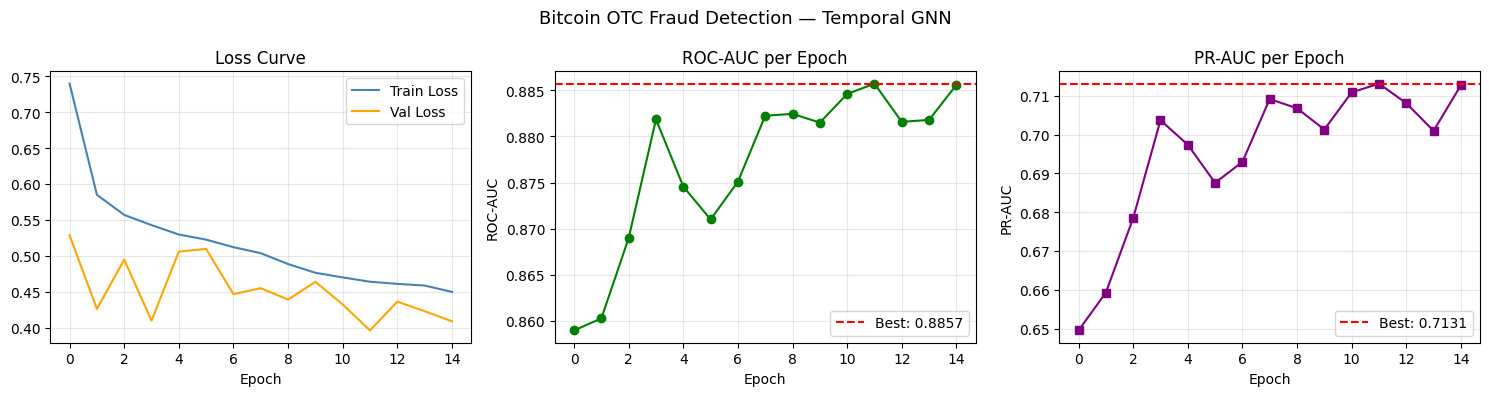

Saved: training_curves.png


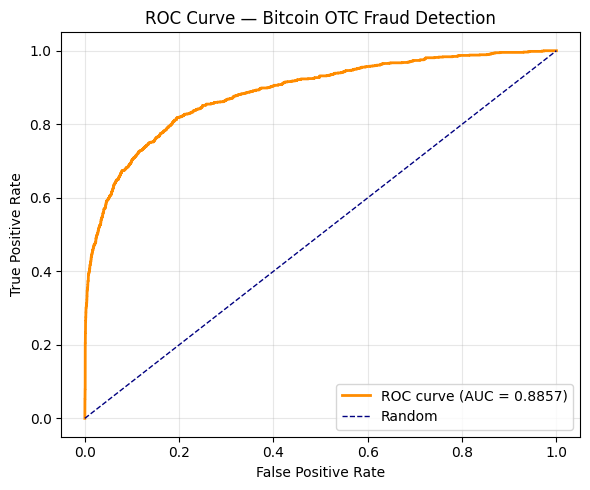

Saved: roc_curve.png

Classification Report (threshold=0.5):
                precision    recall  f1-score   support

   Trusted (0)       0.95      0.84      0.89      6024
Fraudulent (1)       0.47      0.77      0.58      1095

      accuracy                           0.83      7119
     macro avg       0.71      0.81      0.74      7119
  weighted avg       0.88      0.83      0.85      7119


🔥 Final Results:
                      Model                   Dataset ROC-AUC PR-AUC Fraud Rate Framework
Temporal GNN (GRU + Memory) Bitcoin OTC Trust Network  0.8857 0.7131        10%   PyTorch


In [7]:
# Cell 7 — Results, plots, classification report

# ── 1. Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['epoch'], history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('Loss Curve');  axes[0].set_xlabel('Epoch')
axes[0].legend();  axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], history['roc_auc'], color='green', marker='o')
axes[1].set_title('ROC-AUC per Epoch');  axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC');  axes[1].grid(True, alpha=0.3)
axes[1].axhline(best_roc_auc, color='red', linestyle='--',
                label=f'Best: {best_roc_auc:.4f}')
axes[1].legend()

axes[2].plot(history['epoch'], history['pr_auc'], color='purple', marker='s')
axes[2].set_title('PR-AUC per Epoch');  axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('PR-AUC');  axes[2].grid(True, alpha=0.3)
axes[2].axhline(best_val_auc, color='red', linestyle='--',
                label=f'Best: {best_val_auc:.4f}')
axes[2].legend()

plt.suptitle('Bitcoin OTC Fraud Detection — Temporal GNN', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

# ── 2. ROC curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(best_y_true, best_y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {best_roc_auc:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate');  plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Bitcoin OTC Fraud Detection')
plt.legend();  plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve.png")

# ── 3. Classification report at best threshold ────────────────────────────────
threshold = 0.5
y_pred    = (best_y_prob >= threshold).astype(int)
print(f"\nClassification Report (threshold={threshold}):")
print(classification_report(best_y_true, y_pred,
                             target_names=['Trusted (0)', 'Fraudulent (1)']))

# ── 4. Summary table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':      'Temporal GNN (GRU + Memory)',
    'Dataset':    'Bitcoin OTC Trust Network',
    'ROC-AUC':   f"{best_roc_auc:.4f}",
    'PR-AUC':    f"{best_val_auc:.4f}",
    'Fraud Rate': '10%',
    'Framework':  'PyTorch'
}])
print("\n🔥 Final Results:")
print(results_df.to_string(index=False))
